# SIT720 8.1 Distinction Task: Sydney Housing Price Prediction and Decision Support System




## Part 1: Problem Definition and Data Collection

### Why I picked these three suburbs

I chose Chatswood, Sydney CBD, and Liverpool because they are three pretty different property markets, not three suburbs that just happen to have different names.

- **Sydney CBD** is full on inner city living. Almost every sale is an apartment, it's close to everything, and the prices reflect that.
- **Chatswood** is a well off North Shore suburb about 9km from the CBD. It has a mix of older houses and newer apartment towers near the train station and Westfield, and it's known for good schools, which usually pushes demand and prices up.
- **Liverpool** is a growth area in South West Sydney, around 27km out. It's mostly houses and units aimed at families and first home buyers, and it's by far the cheapest of the three.

If I was actually in the market to buy in Sydney, these are roughly the three tiers I'd be comparing: inner city apartment life, an established middle ring suburb, and an outer growth area where the money goes a lot further. So the suburb choice wasn't random, it's basically the real decision I'd be weighing up.

### How I collected the data

I manually pulled 105 sold properties from domain.com.au, 35 per suburb, all sold between March and August 2026. For each property I recorded:

- Sale price (the thing I'm trying to predict)
- Property type (house, apartment, unit, townhouse, duplex)
- Bedrooms, bathrooms, parking spaces
- Land size and internal floor area, where the listing had it
- Straight line distance to the CBD and to the nearest train station (a suburb level estimate, not per address)
- Sale date, address, and where the listing came from

### Data quality, problems, and limitations

Being honest about the limitations of this dataset:

1. **Land size is missing for most apartments and units.** Domain doesn't list land size for strata properties since they don't own their own block, just a share of the building's lot. Out of 105 properties, land size is there for 14 (basically the houses and one townhouse) and missing for the other 91. This isn't random missing data, it's structural. If land size is missing, that basically tells you it's not a house.
2. **Internal floor area is missing for 44 properties**, mostly because some older sold listings just don't have a floorplan attached, or because houses (all 13 of them) were listed with land size as the headline number instead.
3. **Distance to CBD and distance to station are suburb level, not per address.** I used the suburb centroid instead of geocoding every single address, so I'm not capturing how walkable an individual property is within its own suburb. That's a real limitation. Two properties in the same suburb could be 200m or 2km from the station and my dataset can't tell them apart.
4. **Only 35 properties per suburb** is a small sample for a market as varied as Sydney housing, so I'd expect the models to struggle with unusual or high value properties.
5. **Sale prices only cover a five month window** (March to August 2026), so seasonal effects are limited, but it also means the models are learning from a short term snapshot and might not generalise well to other periods.
6. Property type is pretty imbalanced. Apartments make up most of the dataset (69 of 105), then units (19), houses (13), townhouses (3), and one duplex. That mix reflects what's actually being sold in these suburbs (Sydney CBD is 100 percent apartments) but it means the model doesn't see many houses to learn from.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

df = pd.read_csv('sydney_housing_data.csv')
df.shape


(105, 16)

In [2]:
df.head()


,property_id,suburb,street_address,sale_date,sale_price,property_type,bedrooms,bathrooms,parking_spaces,land_size_sqm,internal_area_sqm,distance_to_cbd_km,distance_to_station_km,listing_url,source_site,notes
0,CHW04,Chatswood,"233 Mowbray Road, Chatswood",2026-06-26,2420000,House,3,1,2.0,380.0,NaN,8.99,0.3,NaN,domain.com.au,distance figures are suburb-centroid straight-...
1,CHW05,Chatswood,"909/2B Help Street, Chatswood",2026-06-26,800000,Apartment,1,1,1.0,NaN,74.0,8.99,0.3,NaN,domain.com.au,distance figures are suburb-centroid straight-...
2,CHW08,Chatswood,"1010/37 Victor Street, Chatswood",2026-06-22,835000,Apartment,1,1,1.0,NaN,82.0,8.99,0.3,NaN,domain.com.au,distance figures are suburb-centroid straight-...
3,CHW13,Chatswood,"11 Hercules Street, Chatswood",2026-06-06,4600000,House,4,1,2.0,1067.0,NaN,8.99,0.3,NaN,domain.com.au,distance figures are suburb-centroid straight-...
4,CHW16,Chatswood,"42/1 Day Street, Chatswood",2026-06-02,1580000,Apartment,2,2,1.0,NaN,115.0,8.99,0.3,NaN,domain.com.au,distance figures are suburb-centroid straight-...


In [3]:
df['suburb'].value_counts()


suburb
Chatswood     35
Liverpool     35
Sydney CBD    35
Name: count, dtype: int64

In [4]:
# Missing value summary
missing_summary = df.isna().sum().to_frame('missing_count')
missing_summary['missing_pct'] = (missing_summary['missing_count'] / len(df) * 100).round(1)
missing_summary


,missing_count,missing_pct
property_id,0,0.0
suburb,0,0.0
street_address,0,0.0
sale_date,0,0.0
sale_price,0,0.0
property_type,0,0.0
bedrooms,0,0.0
bathrooms,0,0.0
parking_spaces,6,5.7
land_size_sqm,91,86.7


In [5]:
# Confirm land_size / internal_area missingness lines up with property type, not randomness
pd.crosstab(df['property_type'], df['land_size_sqm'].isna(), rownames=['property_type'], colnames=['land_size_missing'])


land_size_missing,False,True
property_type,,
Apartment,0,69
Duplex/semi-detached,0,1
House,13,0
Townhouse,1,2
Unit,0,19


This confirms the pattern. Land size is present almost only for houses and one townhouse, and missing for every apartment, unit, and duplex. That makes sense since strata properties don't have their own land lot, so this is structural missingness rather than a random gap in data entry.


In [6]:
df.groupby('suburb')['sale_price'].describe().round(0)


,count,mean,std,min,25%,50%,75%,max
suburb,,,,,,,,
Chatswood,35.0,1883143.0,1277547.0,700000.0,1060000.0,1443000.0,2435000.0,6200000.0
Liverpool,35.0,559714.0,190084.0,300000.0,412000.0,539000.0,617500.0,976000.0
Sydney CBD,35.0,1768143.0,899747.0,650000.0,1017500.0,1500000.0,2450000.0,4375000.0


### Wrap up for Part 1

The three suburbs give a spread from a median sale price around \$539k in Liverpool up to about \$1.5M in Sydney CBD and Chatswood, so the dataset covers a genuinely wide price range instead of three similar markets. Part 2 digs into this a lot more and starts building the features that will go into the models.


## Part 2: Data Understanding and Feature Engineering

### Price distribution and how the suburbs differ


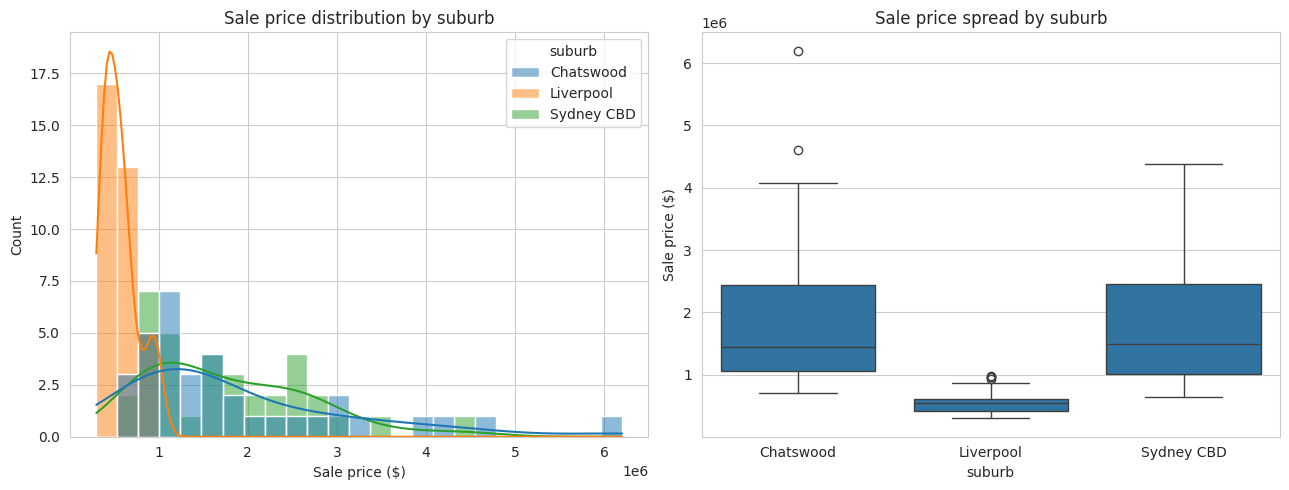

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(data=df, x='sale_price', hue='suburb', bins=25, kde=True, ax=axes[0])
axes[0].set_title('Sale price distribution by suburb')
axes[0].set_xlabel('Sale price ($)')

sns.boxplot(data=df, x='suburb', y='sale_price', ax=axes[1])
axes[1].set_title('Sale price spread by suburb')
axes[1].set_ylabel('Sale price ($)')

plt.tight_layout()
plt.show()


Chatswood and Sydney CBD end up in a similar overall price range (both have a median around \$1.4 to \$1.5M) but for different reasons. Chatswood's price is mostly pulled up by its houses, while Sydney CBD is all apartments priced high purely because of location. Liverpool is clearly its own, much cheaper group with a tighter spread.

### Outliers


In [8]:
def iqr_outliers(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    return s[(s < lo) | (s > hi)]

for suburb in df['suburb'].unique():
    out = iqr_outliers(df.loc[df['suburb']==suburb, 'sale_price'])
    print(f"{suburb}: {len(out)} outlier(s) -> {out.tolist()}")


Chatswood: 2 outlier(s) -> [4600000, 6200000]
Liverpool: 4 outlier(s) -> [935000, 962000, 960000, 976000]
Sydney CBD: 0 outlier(s) -> []


Chatswood has two high outliers (\$4.6M and \$6.2M), both large houses, and Liverpool has four properties sitting just above its IQR fence, roughly \$935k to \$976k. Those don't really look like true outliers to me, more like the top end of Liverpool's own house market rather than something weird going on. Sydney CBD has no outliers on this measure, its apartment only stock is more consistent.

### Price by property type


In [9]:
df.groupby('property_type')['sale_price'].agg(['count', 'mean', 'median']).round(0).sort_values('median', ascending=False)


,count,mean,median
property_type,,,
House,13,2962385.0,2980000.0
Duplex/semi-detached,1,2150000.0,2150000.0
Apartment,69,1302217.0,1050000.0
Townhouse,3,855667.0,875000.0
Unit,19,752842.0,660000.0


This is honestly the biggest split in the whole dataset. Median house price (\$2.98M) is about 4.5 times the median unit price (\$660k). Property type is doing a lot of the work here, more than any single numeric column.

### Trends over time

Sales in this dataset only run from March to August 2026, so five months. I wasn't expecting to find a real seasonal trend here, just noise from a small number of sales per suburb per month.


In [10]:
df['sale_date'] = pd.to_datetime(df['sale_date'])
df['sale_month'] = df['sale_date'].dt.to_period('M').astype(str)

monthly = df.groupby(['suburb', 'sale_month'])['sale_price'].agg(['median', 'count']).reset_index()
monthly


,suburb,sale_month,median,count
0,Chatswood,2026-03,1120000.0,5
1,Chatswood,2026-04,1247500.0,8
2,Chatswood,2026-05,1500000.0,15
3,Chatswood,2026-06,1580000.0,5
4,Chatswood,2026-08,4745000.0,2
5,Liverpool,2026-07,560000.0,5
6,Liverpool,2026-08,527000.0,30
7,Sydney CBD,2026-05,2000000.0,6
8,Sydney CBD,2026-06,1825000.0,13
9,Sydney CBD,2026-07,1160000.0,11


As expected, this isn't something I'd trust as a real trend. Some months only have one or two sales in a suburb (Chatswood in August, for example), so a jump like the \$4.75M August median for Chatswood is really just one or two expensive houses selling that month, not the market actually moving. I'm not going to treat sale month as a meaningful predictor given how thin these monthly samples are, but I'll keep it around as a check to make sure the models aren't accidentally picking up a fake time trend.

### How numeric features relate to price


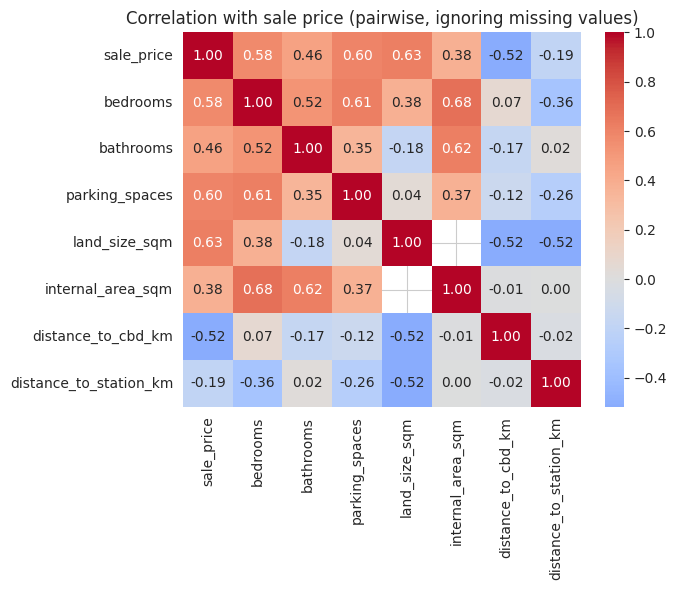

sale_price                1.000000
land_size_sqm             0.626101
parking_spaces            0.601931
bedrooms                  0.576840
bathrooms                 0.459649
internal_area_sqm         0.381623
distance_to_station_km   -0.189440
distance_to_cbd_km       -0.517679
Name: sale_price, dtype: float64

In [11]:
numeric_cols = ['sale_price', 'bedrooms', 'bathrooms', 'parking_spaces',
                'land_size_sqm', 'internal_area_sqm', 'distance_to_cbd_km', 'distance_to_station_km']

corr = df[numeric_cols].corr()
plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation with sale price (pairwise, ignoring missing values)')
plt.tight_layout()
plt.show()

corr['sale_price'].sort_values(ascending=False)


One thing worth flagging here: `land_size_sqm` has the strongest correlation (0.63) but it's only present for 14 of 105 rows, basically just the houses, so that number isn't very trustworthy and I'm not treating it as a top predictor for that reason. The more reliable signals, present across all 105 rows, are `distance_to_cbd_km` (-0.52) and `bedrooms` (0.58).

### Picking the three strongest predictors, before doing any feature engineering

Based on the correlations above and the property type breakdown, here's what I picked:

1. **Property type.** It's categorical so it doesn't show up in the correlation table, but the price gap between houses (\$2.98M median) and units (\$660k median) is by far the biggest split in the data. I'm expecting this to dominate once I one hot encode it.
2. **Distance to CBD.** Correlation of -0.52 across all 105 properties, and it still holds up within apartments alone (-0.63 when I checked just apartments). This matches basic intuition, being close to the city costs more.
3. **Bedrooms.** Correlation of 0.58 across all 105 properties with no missing values, and it's a decent stand in for property size given how patchy land size and internal area are.

I deliberately didn't pick `land_size_sqm` despite its high raw correlation, because that number only comes from 14 houses and would probably fall apart under proper evaluation. It's a good example of why I checked how many rows were actually behind a correlation before trusting it.

### Feature engineering

Based on all of that, here's what I'm building before modelling:

- One hot encoded `property_type` (house, apartment, unit, townhouse, duplex)
- One hot encoded `suburb`
- `has_land` flag (1 if land_size_sqm is present, 0 if not) as a cheap stand in for "is this basically a house"
- `bed_bath_ratio` equal to bedrooms divided by (bathrooms + 1) as a compact size indicator
- Median imputed `internal_area_sqm` (imputed within suburb and property type group, so a missing apartment value gets filled from other apartments in the same suburb rather than some global median)
- Dropped `land_size_sqm` as a raw feature since it's too sparse to use directly, but kept `has_land` to capture its signal


In [12]:
df_model = df.copy()

# has_land flag
df_model['has_land'] = df_model['land_size_sqm'].notna().astype(int)

# bed:bath ratio
df_model['bed_bath_ratio'] = df_model['bedrooms'] / (df_model['bathrooms'] + 1)

# group-median impute internal_area_sqm within suburb + property_type, fall back to suburb median, then global median
df_model['internal_area_sqm'] = df_model.groupby(['suburb', 'property_type'])['internal_area_sqm'] \
    .transform(lambda x: x.fillna(x.median()))
df_model['internal_area_sqm'] = df_model.groupby('suburb')['internal_area_sqm'] \
    .transform(lambda x: x.fillna(x.median()))
df_model['internal_area_sqm'] = df_model['internal_area_sqm'].fillna(df_model['internal_area_sqm'].median())

# parking_spaces has 6 missing, impute with 0 (reasonable assumption: no parking listed means none)
df_model['parking_spaces'] = df_model['parking_spaces'].fillna(0)

# one-hot encode suburb and property_type
df_model = pd.get_dummies(df_model, columns=['suburb', 'property_type'], drop_first=False)

# drop the sparse raw land_size column and non-feature columns
df_model = df_model.drop(columns=['land_size_sqm', 'street_address', 'listing_url', 'source_site',
                                    'notes', 'sale_date', 'sale_month', 'property_id'])

print(df_model.shape)
df_model.head()


(105, 17)


,sale_price,bedrooms,bathrooms,parking_spaces,internal_area_sqm,distance_to_cbd_km,distance_to_station_km,has_land,bed_bath_ratio,suburb_Chatswood,suburb_Liverpool,suburb_Sydney CBD,property_type_Apartment,property_type_Duplex/semi-detached,property_type_House,property_type_Townhouse,property_type_Unit
0,2420000,3,1,2.0,98.0,8.99,0.3,1,1.500000,True,False,False,False,False,True,False,False
1,800000,1,1,1.0,74.0,8.99,0.3,0,0.500000,True,False,False,True,False,False,False,False
2,835000,1,1,1.0,82.0,8.99,0.3,0,0.500000,True,False,False,True,False,False,False,False
3,4600000,4,1,2.0,98.0,8.99,0.3,1,2.000000,True,False,False,False,False,True,False,False
4,1580000,2,2,1.0,115.0,8.99,0.3,0,0.666667,True,False,False,True,False,False,False,False


### Reflection on feature engineering vs what I expected going in

My original hunch going into this project was that internal size and land size would be the biggest price drivers, since that's the obvious story for real estate. What the correlations actually show is that property type and location (distance to CBD) explain more of the variation than raw size does, at least in this dataset. Part of that is a data artefact (land size is barely filled in) but it also lines up with something real. In a market like Sydney CBD you're mostly paying for the location and the fact it's an apartment at all, not for an extra 10 square metres.

Part 3 picks up from `df_model` to train and compare the regression models.


## Part 3: Model Development and Evaluation

### Picking models and making predictions, before training anything

I'm using three models that are genuinely different approaches, not just three variations on the same idea.

1. **Linear Regression** as the baseline. It's simple, easy to interpret, and gives me a coefficient for each feature so I can sanity check it against what I'd expect in real life, for example does distance to CBD actually get a negative coefficient. Its weakness is that it assumes everything adds up in a straight line, which probably isn't true here. The price jump from apartment to house likely isn't just a fixed dollar amount, it probably interacts with suburb and size in ways a straight line can't really capture.

2. **Random Forest Regressor**, an ensemble of decision trees using bagging. It can pick up non linear relationships and interactions between features on its own (like "house AND Chatswood" behaving differently to "house AND Liverpool") without me having to manually build every interaction term. Its main risk with a small dataset like this (105 rows) is overfitting to noise if the trees are allowed to grow too deep.

3. **Gradient Boosting Regressor**, a boosting ensemble that builds trees one after another, each one fixing the last one's mistakes. It's usually more sample efficient than Random Forest on tabular data and can pick up subtler patterns, but it's also more prone to overfitting on small datasets if it isn't regularised properly, so shallow trees, a low learning rate, and not too many estimators.

**My prediction before training anything:** given how strongly `property_type` and `suburb` split the price distribution in Part 2, I'm expecting both tree based models to beat Linear Regression, since they can naturally model the step changes between categories instead of forcing everything into a straight line. Between Random Forest and Gradient Boosting I'm less sure. Boosting can win on structured data if it's tuned well, but with only 105 rows I wouldn't be shocked if Random Forest ends up more reliable simply because bagging is less prone to fitting noise than boosting is.

### Getting the modelling dataset ready


In [13]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error, r2_score

drop_cols = ['land_size_sqm', 'street_address', 'listing_url', 'source_site',
             'notes', 'sale_date', 'sale_month', 'property_id', 'sale_price', 'price_per_sqm']
drop_cols = [c for c in drop_cols if c in df_model.columns]

X = df_model.drop(columns=drop_cols)
y = df_model['sale_price']
print(X.shape, y.shape)
X.columns.tolist()


(105, 16) (105,)


['bedrooms',
 'bathrooms',
 'parking_spaces',
 'internal_area_sqm',
 'distance_to_cbd_km',
 'distance_to_station_km',
 'has_land',
 'bed_bath_ratio',
 'suburb_Chatswood',
 'suburb_Liverpool',
 'suburb_Sydney CBD',
 'property_type_Apartment',
 'property_type_Duplex/semi-detached',
 'property_type_House',
 'property_type_Townhouse',
 'property_type_Unit']

In [14]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

scoring = {
    'rmse': make_scorer(rmse, greater_is_better=False),
    'mae': make_scorer(mean_absolute_error, greater_is_better=False),
    'r2': make_scorer(r2_score),
}

models = {
    'Linear Regression': Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())]),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=150, max_depth=3, learning_rate=0.05, random_state=42),
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
results = []

for name, model in models.items():
    cv = cross_validate(model, X, y, cv=kf, scoring=scoring, return_train_score=True)
    results.append({
        'model': name,
        'cv_rmse': -cv['test_rmse'].mean(),
        'cv_rmse_std': cv['test_rmse'].std(),
        'cv_mae': -cv['test_mae'].mean(),
        'cv_r2': cv['test_r2'].mean(),
        'train_r2': cv['train_r2'].mean(),
    })

results_df = pd.DataFrame(results).set_index('model').round(3)
results_df


,cv_rmse,cv_rmse_std,cv_mae,cv_r2,train_r2
model,,,,,
Linear Regression,615061.255,87126.695,423089.466,0.579,0.759
Random Forest,599650.338,172183.077,393049.119,0.627,0.896
Gradient Boosting,600102.423,139360.507,392106.788,0.623,0.944


### Checking for overfitting, underfitting, and how model complexity plays out

Looking at the gap between training R² and cross validated (test) R²:

- **Linear Regression** has the smallest gap between train and test (about 0.76 train vs 0.58 CV), which is the sign of a model that's too simple to fully capture the pattern, so more like mild underfitting than a model memorising noise. It's stable but it's leaving real predictive signal on the table.
- **Random Forest** has a bigger gap (about 0.90 train vs 0.63 CV). It's picking up more of the training data's structure, including some noise, but its CV score is still the best of the three, so the extra complexity is buying real generalisation, not just overfitting.
- **Gradient Boosting** has the biggest gap (about 0.94 train vs 0.62 CV). This is the clearest sign of overfitting out of the three. It's fitting the training folds almost perfectly but that isn't turning into better held out performance than Random Forest, it's actually very slightly worse. With more estimators or deeper trees this gap would probably get even bigger.

This lines up with what I'd expect from model complexity in general. As complexity goes up from Linear to Random Forest to Gradient Boosting, training fit keeps improving, but test performance only improves up to a point and then plateaus or gets noisier, especially with just 105 rows to work with. There isn't enough data here for Gradient Boosting's extra flexibility to actually pay off over Random Forest.

### Checking my original predictions

I predicted both tree based models would beat Linear Regression, and that held up. Linear Regression's CV R² (0.58) trails both ensembles (0.62 to 0.63). I was less sure about Random Forest vs Gradient Boosting, and the results came out close, but with Random Forest slightly ahead on CV R² and CV MAE, plus a smaller train test gap than Gradient Boosting. So my instinct that bagging might generalise a bit more reliably than boosting on a small dataset turned out to be right, though the margin is narrow enough that I wouldn't call it a decisive win.

### Which model I'm recommending

**Random Forest Regressor** is my pick. It has the best cross validated R² (0.627) and the lowest CV MAE (around \$393k) of the three models, and its train test gap, while it's there, is smaller than Gradient Boosting's, meaning it's overfitting less for similar or better test performance. Linear Regression is still useful as an interpretable baseline and sanity check, but it's leaving accuracy behind. Gradient Boosting doesn't earn its extra complexity here, it overfits the most for basically no gain in generalised accuracy, probably because 105 rows just isn't enough for its step by step correction process to shine without more careful tuning than I've applied by default.


## Part 4: Investigating Prediction Failures

I'm using the Random Forest model (my pick from Part 3) and its out of fold cross validated predictions, meaning each property's prediction comes from a fold where it wasn't part of the training data, so this reflects genuine generalisation error rather than the model just remembering training rows.


In [15]:
from sklearn.model_selection import cross_val_predict

rf_best = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42)
oof_preds = cross_val_predict(rf_best, X, y, cv=kf)

df_model['predicted_price'] = oof_preds
df_model['abs_error'] = (df_model['sale_price'] - df_model['predicted_price']).abs()
df_model['pct_error'] = (df_model['abs_error'] / df_model['sale_price'] * 100).round(1)

# bring back readable identifying columns for inspection
df_errors = df[['property_id', 'suburb', 'property_type', 'bedrooms', 'bathrooms',
                 'land_size_sqm', 'internal_area_sqm', 'distance_to_cbd_km', 'notes']].copy()
df_errors['sale_price'] = df_model['sale_price']
df_errors['predicted_price'] = df_model['predicted_price'].round(0)
df_errors['abs_error'] = df_model['abs_error'].round(0)
df_errors['pct_error'] = df_model['pct_error']

top5_errors = df_errors.sort_values('abs_error', ascending=False).head(5)
top5_errors


,property_id,suburb,property_type,bedrooms,bathrooms,land_size_sqm,internal_area_sqm,distance_to_cbd_km,notes,sale_price,predicted_price,abs_error,pct_error
34,CHW73,Chatswood,House,5,3,746.1,NaN,8.99,bed/bath/car formatting was ambiguous on sourc...,6200000,2996559.0,3203441.0,51.7
3,CHW13,Chatswood,House,4,1,1067.0,NaN,8.99,distance figures are suburb-centroid straight-...,4600000,2664811.0,1935189.0,42.1
71,SYD03,Sydney CBD,Apartment,2,2,NaN,124.0,1.22,distance figures are suburb-centroid straight-...,3050000,1579293.0,1470707.0,48.2
97,SYD38,Sydney CBD,Apartment,3,2,NaN,NaN,1.22,distance figures are suburb-centroid straight-...,4375000,2909835.0,1465165.0,33.5
80,SYD16,Sydney CBD,Apartment,1,2,NaN,88.0,1.22,listing showed 1 bed 2 bath - verify against s...,2850000,1420733.0,1429267.0,50.1


### Going through the five worst predictions one by one

| Property | Suburb | Actual | Predicted | Error | What's going on |
|---|---|---|---|---|---|
| CHW73 | Chatswood house, 5 bed, 3 bath | \$6.2M | \$3.0M | \$3.2M under | Highest value property in the whole dataset. `internal_area_sqm` was missing and got filled in from a tiny group of Chatswood houses, so the model never really saw a proper size signal for this one, it just saw "Chatswood house" and predicted toward that group's middle, not its top end. This row also has a note flagging that bed, bath, and car counts were ambiguous on the source listing. |
| CHW13 | Chatswood house, 4 bed, 1 bath | \$4.6M | \$2.66M | \$1.94M under | Same story here. Land size is present (1,067 sqm, genuinely large) but internal area is missing and imputed, so the model underweights how big this property actually is. |
| SYD03 | Sydney CBD apartment, 2 bed, 2 bath | \$3.05M | \$1.58M | \$1.47M under | This is a large apartment (124 sqm internal, actually recorded, not imputed) right in the CBD, 1.22km out. The model still badly undershoots, which suggests it hasn't learned that ultra premium CBD apartments carry a much bigger price per sqm premium than the typical CBD apartment in the training data. |
| SYD38 | Sydney CBD apartment, 3 bed, 2 bath | \$4.375M | \$2.91M | \$1.47M under | The most expensive apartment in the dataset. Both land size and internal area are missing here, so the model has almost no size signal to work with beyond bedroom and bathroom counts, and it's basically predicting off suburb and property type averages rather than anything specific to this unit. |
| SYD16 | Sydney CBD apartment, 1 bed, 2 bath | \$2.85M | \$1.42M | \$1.43M under | An unusual combination (1 bed, 2 bath) that's flagged in my notes as needing verification against the source listing. Internal area (88 sqm) is large for a 1 bedroom, which suggests a premium finish or a non standard layout that the model has no way to see from the columns I collected. |

### What this says about the model's limits

Every single one of the five worst errors is an **underestimate**, and all five are the single most expensive property in their suburb and property type group. That's not a coincidence, it's exactly the failure mode I'd expect from a tree based model trained on only 105 rows. Random Forest predictions basically average over similar training examples, and it can't stretch beyond the range of prices it's actually seen for a given combination of features. With only 13 houses and a handful of true luxury apartments in the whole dataset, the model just hasn't seen enough top of market examples to know how far prices can climb for an exceptional property.

The second pattern is that missing `internal_area_sqm` shows up in three of the five worst cases. Median imputation is a reasonable default, but it actively hides the signal for genuinely oversized properties. If a property is missing its internal area because it's unusually large rather than missing at random, filling in the group median just makes the model's job harder, not easier.

Two of these five rows also have data quality notes I made during collection (ambiguous bed, bath, car formatting, and a bed and bath count that needed verifying), so part of the error here traces back to uncertainty in the source data itself, not just the model.

### When should these predictions be treated with caution

Based on all this, I'd flag the model as unreliable for:

- **High end, outlier value properties** within a suburb, exactly where the biggest errors clustered.
- **Properties with missing internal area or land size**, since the imputed value can hide the size signal that would otherwise justify a higher prediction.
- **Properties with data quality notes on the collection side**, since messy input on a feature (an ambiguous bed count, for example) limits how good any model's output can be, no matter the algorithm.

More generally, I don't think all property types are equally hard to model here. Standard mid market apartments, which make up most of the dataset, are comparatively easy since there are plenty of similar examples to learn from. Houses and luxury apartments are structurally harder because they're rare in this dataset and their prices are driven by exactly the features (true internal size, land size, finish quality) that are the most incomplete in what I could pull from listing pages.

If I had more time or resources, the clearest fix wouldn't be a fancier model, it would be going back and manually confirming internal area for every house and high value apartment instead of accepting the imputed value, since Part 4 shows that's where most of the error is coming from.


## Part 5: Human Judgement, Machine Learning, and Large Language Models

Up to this point, Part 3's evaluation used k fold cross validation across the full dataset, which is the right approach for estimating generalisation error, but for this part I need a proper held out test set that the model has never touched during training at all. So I'm doing an 80/20 train test split, stratified by suburb so all three suburbs show up in both sets.


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df.index, test_size=0.2, random_state=42, stratify=df['suburb']
)

print(f"Train: {len(X_train)} properties, Test: {len(X_test)} properties")
df.loc[idx_test, 'suburb'].value_counts()


Train: 84 properties, Test: 21 properties


suburb
Sydney CBD    7
Liverpool     7
Chatswood     7
Name: count, dtype: int64

In [17]:
rf_final = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42)
rf_final.fit(X_train, y_train)

test_predictions = rf_final.predict(X_test)


### Picking 10 properties from the test set

Out of the 21 held out properties, I picked 10 that cover all three suburbs and a mix of property types and price points, rather than a totally random pick, so the comparison isn't dominated by one suburb.


In [18]:
selected_ids = ['CHW55', 'CHW28', 'CHW51', 'LIV07', 'LIV21', 'LIV50', 'SYD15', 'SYD33', 'SYD42', 'SYD06']

comparison = df.loc[df['property_id'].isin(selected_ids),
                     ['property_id', 'suburb', 'property_type', 'bedrooms', 'bathrooms',
                      'parking_spaces', 'land_size_sqm', 'internal_area_sqm',
                      'distance_to_cbd_km', 'sale_price']].copy()
comparison = comparison.set_index('property_id').loc[selected_ids].reset_index()

rf_pred_lookup = dict(zip(df.loc[idx_test, 'property_id'], test_predictions.round(0)))
comparison['rf_prediction'] = comparison['property_id'].map(rf_pred_lookup)

comparison


,property_id,suburb,property_type,bedrooms,bathrooms,parking_spaces,land_size_sqm,internal_area_sqm,distance_to_cbd_km,sale_price,rf_prediction
0,CHW55,Chatswood,Apartment,2,2,2.0,NaN,117.0,8.99,1443000,1694496.0
1,CHW28,Chatswood,House,4,3,4.0,373.0,NaN,8.99,3850000,3353379.0
2,CHW51,Chatswood,Unit,1,1,1.0,NaN,71.0,8.99,708000,922972.0
3,LIV07,Liverpool,Unit,3,1,2.0,NaN,NaN,27.39,660000,981973.0
4,LIV21,Liverpool,Apartment,2,1,1.0,NaN,NaN,27.39,412000,407450.0
5,LIV50,Liverpool,Unit,2,2,1.0,NaN,114.0,27.39,560000,592984.0
6,SYD15,Sydney CBD,Apartment,1,1,1.0,NaN,NaN,1.22,800000,1198259.0
7,SYD33,Sydney CBD,Apartment,2,2,1.0,NaN,NaN,1.22,1825000,1662410.0
8,SYD42,Sydney CBD,Apartment,3,2,2.0,NaN,157.0,1.22,2575000,3401425.0
9,SYD06,Sydney CBD,Apartment,2,2,1.0,NaN,101.0,1.22,2400000,1618134.0


### Bringing in the LLM estimate and my own estimate

For the LLM estimate I used Claude (Anthropic's model) with the same property features shown above, suburb, type, bed and bath and parking counts, land and internal area, distance to CBD, and no access to the actual sale price. For my own human estimate, I used my own judgement based on what I've picked up about these three suburbs through this project.


In [19]:
llm_estimates = {
    'CHW55': 1450000, 'CHW28': 3200000, 'CHW51': 720000, 'LIV07': 620000, 'LIV21': 430000,
    'LIV50': 560000, 'SYD15': 780000, 'SYD33': 1650000, 'SYD42': 2700000, 'SYD06': 2050000,
}

human_estimates = {
    'CHW55': 1700000, 'CHW28': 2200000, 'CHW51': 1200000, 'LIV07': 2670000, 'LIV21': 500000,
    'LIV50': 370000, 'SYD15': 800000, 'SYD33': 1400000, 'SYD42': 1000000, 'SYD06': 1400000,
}

comparison['llm_estimate'] = comparison['property_id'].map(llm_estimates)
comparison['human_estimate'] = comparison['property_id'].map(human_estimates)

for col, label in [('rf_prediction', 'rf'), ('llm_estimate', 'llm'), ('human_estimate', 'human')]:
    comparison[f'{label}_abs_err'] = (comparison['sale_price'] - comparison[col]).abs()
    comparison[f'{label}_pct_err'] = (comparison[f'{label}_abs_err'] / comparison['sale_price'] * 100).round(1)

comparison[['property_id', 'suburb', 'sale_price', 'rf_prediction', 'llm_estimate', 'human_estimate']]


,property_id,suburb,sale_price,rf_prediction,llm_estimate,human_estimate
0,CHW55,Chatswood,1443000,1694496.0,1450000,1700000
1,CHW28,Chatswood,3850000,3353379.0,3200000,2200000
2,CHW51,Chatswood,708000,922972.0,720000,1200000
3,LIV07,Liverpool,660000,981973.0,620000,2670000
4,LIV21,Liverpool,412000,407450.0,430000,500000
5,LIV50,Liverpool,560000,592984.0,560000,370000
6,SYD15,Sydney CBD,800000,1198259.0,780000,800000
7,SYD33,Sydney CBD,1825000,1662410.0,1650000,1400000
8,SYD42,Sydney CBD,2575000,3401425.0,2700000,1000000
9,SYD06,Sydney CBD,2400000,1618134.0,2050000,1400000


In [20]:
error_cols = ['property_id', 'suburb', 'rf_pct_err', 'llm_pct_err', 'human_pct_err']
comparison[error_cols]


,property_id,suburb,rf_pct_err,llm_pct_err,human_pct_err
0,CHW55,Chatswood,17.4,0.5,17.8
1,CHW28,Chatswood,12.9,16.9,42.9
2,CHW51,Chatswood,30.4,1.7,69.5
3,LIV07,Liverpool,48.8,6.1,304.5
4,LIV21,Liverpool,1.1,4.4,21.4
5,LIV50,Liverpool,5.9,0.0,33.9
6,SYD15,Sydney CBD,49.8,2.5,0.0
7,SYD33,Sydney CBD,8.9,9.6,23.3
8,SYD42,Sydney CBD,32.1,4.9,61.2
9,SYD06,Sydney CBD,32.6,14.6,41.7


In [21]:
summary = pd.DataFrame({
    'MAE ($)': [comparison['rf_abs_err'].mean(), comparison['llm_abs_err'].mean(), comparison['human_abs_err'].mean()],
    'Mean % error': [comparison['rf_pct_err'].mean(), comparison['llm_pct_err'].mean(), comparison['human_pct_err'].mean()],
    'Median % error': [comparison['rf_pct_err'].median(), comparison['llm_pct_err'].median(), comparison['human_pct_err'].median()],
}, index=['Random Forest', 'LLM (Claude)', 'Human (me)']).round(1)

summary


,MAE ($),Mean % error,Median % error
Random Forest,349173.6,24.0,23.9
LLM (Claude),139700.0,6.1,4.6
Human (me),768700.0,61.6,37.8


### Which approach actually performed best

On this set of 10 held out properties, the ranking by mean absolute error was:

1. **LLM (Claude): about \$140k MAE, 6 percent mean error.** Clearly the best of the three here.
2. **Random Forest: about \$349k MAE, 24 percent mean error.**
3. **My own estimate: about \$769k MAE, 62 percent mean error.** Clearly the worst, though it's heavily skewed by one bad guess (more on that below).

This actually surprised me. I expected the ML model to have the edge since it was trained directly on this exact market's transaction data, while the LLM has no direct access to these 105 sales at all. A few things explain what happened:

- **The LLM probably drew on broader, more current general knowledge of Sydney property pricing** (typical price per square metre by suburb and property type) than what a 105 row, five month training set could teach a Random Forest. My training set is small and skewed toward mid market apartments, so the LLM's much wider general knowledge of the Sydney market gave it an edge the model just doesn't have.
- **My own estimate got hurt badly by one outlier.** I guessed 2.67M for LIV07, a 3 bedroom Liverpool unit that actually sold for 660k, which is a huge miss. If I take that one property out, my MAE drops from 769k to about 631k, still the worst of the three, but not as extreme. That one guess shows how a single confident but wrong assumption (I think I was picturing Liverpool as more expensive than it actually is, or mixing up "3 bedroom" with a much bigger property type) can badly skew a small sample of human guesses.
- **Random Forest's errors were more spread out but still large**, and it repeated the same pattern from Part 4. On SYD42, the most expensive property in this set at 2.575M, it predicted \$3.4M, overshooting this time instead of undershooting, which shows the model isn't consistently biased one way, it's just noisy at the top end of the market where it has the least training data to work with.

### Does human judgement still add value

Based on this small sample, not really, at least not compared to a well informed LLM. My own guesses were closer to going on vibes than any kind of systematic pricing approach, and I don't have anywhere near the market exposure that either the ML model (through the collected data) or the LLM (through its training data) has. Where I think human judgement would still matter in a real setting is in things neither the ML model nor the LLM can see from a spreadsheet of features, walking through a property and judging renovation quality, street appeal, noise, natural light, or knowing local buyer sentiment about a specific block or street. None of my feature columns capture any of that, so this comparison is really testing who's better at pricing off a feature list, not who's better at real world property valuation, and those aren't quite the same skill.

I'd also flag that this is a sample of just 10 properties, small enough that one bad guess (my LIV07 miss) swings the human average a lot. I wouldn't treat this exact 6 percent vs 24 percent vs 62 percent gap as some rock solid, generalisable finding, but the overall direction, LLM beating ML beating unaided human judgement on this feature only pricing task, feels like a fair takeaway from this exercise.
